# 第038讲 Newton与拟Newton方法
同一四行数据，先线性、再平方参数。每一步保留完整前向与曲率账本，最后分开检查实测时间、内存和科学边界。

In [1]:
from pathlib import Path
import hashlib,sys,json,io
ROOT=Path.cwd()
BASELINE={'data/regression.csv': '0bd28e7888af84c067bf6e4cec62e6d44e1e53f663f257d078dd104aaabb9105', 'data/model_spec.json': '638e0d251248eeaa96d5fdfcb814ab4ba0bcd1c400627266d4ac13ab6b0dd82c'}
for name,expected in BASELINE.items():
    if hashlib.sha256((ROOT/name).read_bytes()).hexdigest()!=expected:
        raise ValueError('默认输入已改变，固定说明不适用：'+name)
sys.path.insert(0,str(ROOT))
import experiment as ex
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction as Q
from IPython.display import display,Image
x,y,spec=ex.load_inputs()
def show(fig):
    buf=io.BytesIO();fig.tight_layout();fig.savefig(buf,format='png',dpi=140,bbox_inches='tight');display(Image(data=buf.getvalue()));plt.close(fig)
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':10,'axes.spines.top':False,'axes.spines.right':False})
print('完整默认输入校验通过。Python',sys.version.split()[0],'NumPy',np.__version__)
print('x=',x,'y=',y)

完整默认输入校验通过。Python 3.12.14 NumPy 2.3.5
x= [-2. -2.  2.  2.] y= [-1.5 -0.5  2.5  3.5]


## 1 线性控制：旧行汇总后才同步更新
一轮后残差并不全为零；梯度和恰为零。

In [2]:
linear=ex.optimize(ex.RowObjective(x,y,'linear'),[0,0],spec,'newton')
step=linear['trace'][0]
for phase in ['old','new']:
    print(phase)
    for row in step[phase]['rows']:print(row)
print('direction',step['direction'],'new theta',step['new_theta'],'new F',step['new']['f'])

old
{'id': 1, 'x': -2.0, 'y': -1.5, 'prediction': 0.0, 'residual': 1.5, 'half_square': 1.125, 'loss_contribution': 0.28125, 'local_dloss_dr': 1.5, 'jacobian': [1.0, -2.0], 'gradient_contribution': [0.375, -0.75], 'hessian_J_outer': [[0.25, -0.5], [-0.5, 1.0]], 'hessian_residual_second': [[0.0, 0.0], [0.0, 0.0]], 'hessian_contribution': [[0.25, -0.5], [-0.5, 1.0]]}
{'id': 2, 'x': -2.0, 'y': -0.5, 'prediction': 0.0, 'residual': 0.5, 'half_square': 0.125, 'loss_contribution': 0.03125, 'local_dloss_dr': 0.5, 'jacobian': [1.0, -2.0], 'gradient_contribution': [0.125, -0.25], 'hessian_J_outer': [[0.25, -0.5], [-0.5, 1.0]], 'hessian_residual_second': [[0.0, 0.0], [0.0, 0.0]], 'hessian_contribution': [[0.25, -0.5], [-0.5, 1.0]]}
{'id': 3, 'x': 2.0, 'y': 2.5, 'prediction': 0.0, 'residual': -2.5, 'half_square': 3.125, 'loss_contribution': 0.78125, 'local_dloss_dr': -2.5, 'jacobian': [1.0, 2.0], 'gradient_contribution': [-0.625, -1.25], 'hessian_J_outer': [[0.25, 0.5], [0.5, 1.0]], 'hessian_residu

## 2 独立Fraction生成三张完整表
使用逐行算式，另用二阶2×2行列式解方程。展示分数不反馈到浮点算法。

In [3]:
from audit import rational_rows,qsolve
qx=[Q(v) for v in x];qy=[Q(v) for v in y];paper_theta=[Q(0),Q(3,2)]
for k in range(3):
    F,g,H,rows=rational_rows(qx,qy,paper_theta,'square')
    print('state',k,'theta',[str(v) for v in paper_theta],'F',str(F),'g',[str(v) for v in g],'H',[[str(v)for v in r]for r in H])
    for i,(pred,r,half,J,grow,Hrow) in enumerate(rows):
        print(i+1,'pred',str(pred),'r',str(r),'half_square',str(half),'J',[str(v)for v in J],'gradient_row',[str(v)for v in grow],'Hrow',[[str(v)for v in row]for row in Hrow])
    if k<2:
        p=qsolve(H,g);paper_theta=[paper_theta[j]+p[j]for j in range(2)]

state 0 theta ['0', '3/2'] F 15/4 g ['-1', '15'] H [['1', '0'], ['0', '46']]
1 pred -9/2 r -3 half_square 9/2 J ['1', '-6'] gradient_row ['-3/4', '9/2'] Hrow [['1/4', '-3/2'], ['-3/2', '12']]
2 pred -9/2 r -4 half_square 8 J ['1', '-6'] gradient_row ['-1', '6'] Hrow [['1/4', '-3/2'], ['-3/2', '13']]
3 pred 9/2 r 2 half_square 2 J ['1', '6'] gradient_row ['1/2', '3'] Hrow [['1/4', '3/2'], ['3/2', '11']]
4 pred 9/2 r 1 half_square 1/2 J ['1', '6'] gradient_row ['1/4', '3/2'] Hrow [['1/4', '3/2'], ['3/2', '10']]
state 1 theta ['1', '27/23'] F 919841/2238728 g ['0', '43200/12167'] H [['1', '0'], ['0', '13264/529']]
1 pred -929/529 r -271/1058 half_square 73441/2238728 J ['1', '-108/23'] gradient_row ['-271/4232', '7317/24334'] Hrow [['1/4', '-27/23'], ['-27/23', '6103/1058']]
2 pred -929/529 r -1329/1058 half_square 1766241/2238728 J ['1', '-108/23'] gradient_row ['-1329/4232', '35883/24334'] Hrow [['1/4', '-27/23'], ['-27/23', '7161/1058']]
3 pred 1987/529 r 1329/1058 half_square 1766241/

## 3 核心报告由此内核真实计算
直接逐样本计算，不用闭式轨迹替代。GD在严格1e−10阈值下未达标的状态必须保留。

In [4]:
report=ex.run_experiment(x,y,spec);paths=report['paths']
for name,r in paths.items():print(name,r['status'],'updates',r['accepted_updates'],'gradient norm',r['gradient_norm'],'calls',r['counts'])

linear_gd gradient_stationary updates 7 gradient norm 0.0 calls {'f': 23, 'g': 22, 'H': 23, 'solve': 0, 'cholesky': 0, 'line_trials': 14}
linear_newton gradient_stationary updates 1 gradient norm 0.0 calls {'f': 4, 'g': 3, 'H': 4, 'solve': 1, 'cholesky': 1, 'line_trials': 1}
linear_bfgs gradient_stationary updates 6 gradient norm 2.228664865928395e-12 calls {'f': 15, 'g': 14, 'H': 15, 'solve': 0, 'cholesky': 7, 'line_trials': 7}
linear_lbfgs gradient_stationary updates 8 gradient norm 5.695335695415984e-12 calls {'f': 19, 'g': 18, 'H': 19, 'solve': 0, 'cholesky': 0, 'line_trials': 9}
square_gd max_updates updates 100 gradient norm 1.409914673899948e-08 calls {'f': 495, 'g': 494, 'H': 495, 'solve': 0, 'cholesky': 0, 'line_trials': 393}
square_newton gradient_stationary updates 6 gradient norm 0.0 calls {'f': 14, 'g': 13, 'H': 14, 'solve': 6, 'cholesky': 6, 'line_trials': 6}
square_bfgs gradient_stationary updates 10 gradient norm 2.982879134077876e-11 calls {'f': 27, 'g': 26, 'H': 27, '

## 4 同一目标的不同方向
下图由本次实际状态重新绘制。先问方向是否下降，再问实际步长是否接受。

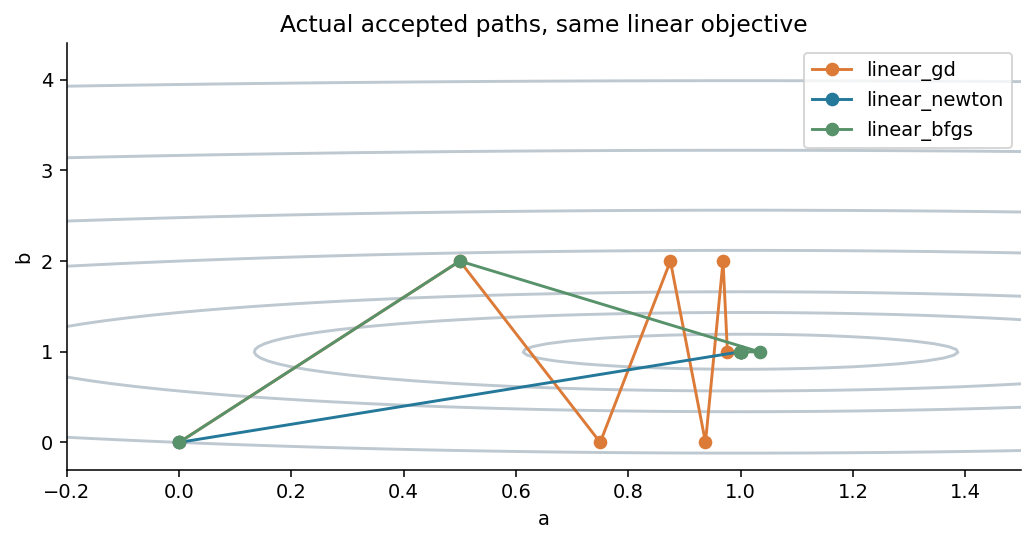

In [5]:
fig,ax=plt.subplots(figsize=(7.5,4));aa,bb=np.meshgrid(np.linspace(-.2,1.5,130),np.linspace(-.3,4.4,150));zz=.125+.5*(aa-1)**2+2*(bb-1)**2
ax.contour(aa,bb,zz,levels=[.2,.5,1,2.625,5,10,18],colors='#bdc8d0')
for name,col in [('linear_gd','#dc7a38'),('linear_newton','#247899'),('linear_bfgs','#57926a')]:
    st=np.array([q['theta']for q in paths[name]['states']]);ax.plot(st[:,0],st[:,1],'o-',label=name,color=col)
ax.set(xlabel='a',ylabel='b',title='Actual accepted paths, same linear objective');ax.legend();show(fig)

## 5 Hessian两项不能混淆
在小b处，残差项会压过非负Jacobian外积，使总曲率为负。

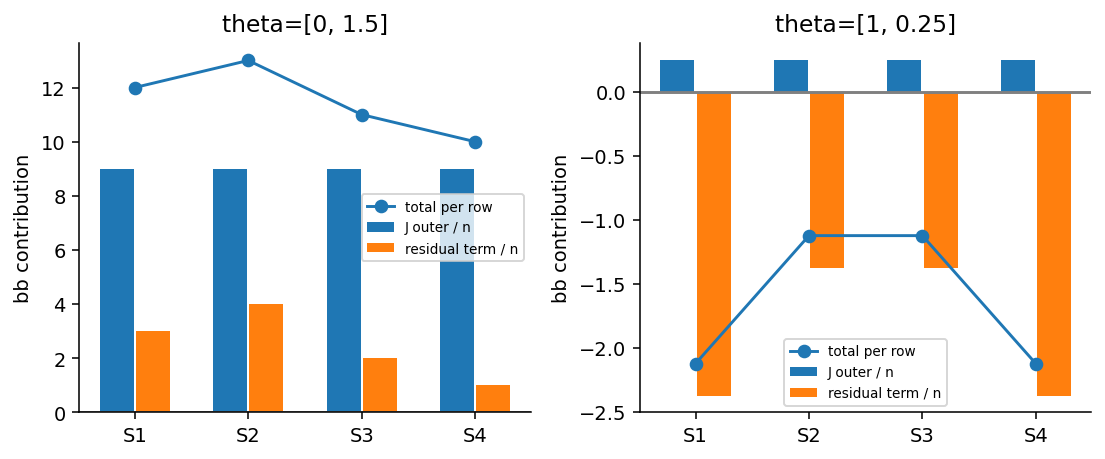

In [6]:
fig,axes=plt.subplots(1,2,figsize=(8,3.4))
for ax,theta in zip(axes,([0,1.5],[1,.25])):
    f=ex.RowObjective(x,y,'square').evaluate(theta,True,True,True);q=np.arange(4);u=np.array([r['hessian_J_outer'][1][1]for r in f['rows']]);v=np.array([r['hessian_residual_second'][1][1]for r in f['rows']])
    ax.bar(q-.16,u,.3,label='J outer / n');ax.bar(q+.16,v,.3,label='residual term / n');ax.plot(q,u+v,'o-',label='total per row');ax.axhline(0,color='gray');ax.set(xticks=q,xticklabels=['S1','S2','S3','S4'],title='theta='+str(theta),ylabel='bb contribution');ax.legend(fontsize=7)
show(fig)

## 6 不正定原方向与实际回溯
λ=8改变局部模型，不改变原训练目标。每次拒绝也保留了完整逐行前向。

raw direction [0.0, -0.28846153846153844] gTp 0.5408653846153846 new F 2.1190872168341444
shift 8.0 direction [-0.0, 1.25]
trial 1.0 [1.0, 1.5] 3.25 1.882578125 armijo_reject
row residuals [-2.0, -3.0, 3.0, 2.0]
trial 0.5 [1.0, 0.875] 0.23486328125 1.8826953125 armijo_accept
row residuals [0.96875, -0.03125, 0.03125, -0.96875]


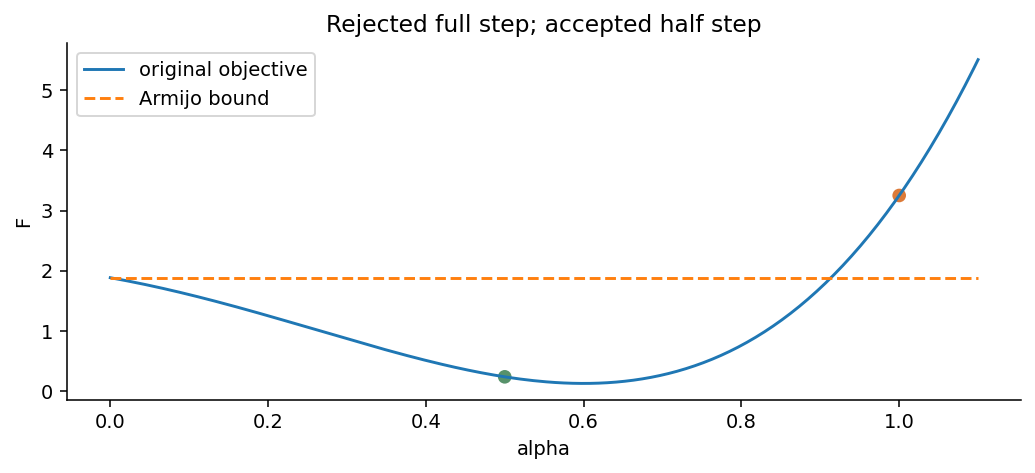

In [7]:
raw=report['raw_indefinite_demo'];print('raw direction',raw['direction'],'gTp',raw['gTp'],'new F',raw['new']['f'])
rec=paths['indefinite_modified_newton']['trace'][0]
print('shift',rec['direction_state']['shift'],'direction',rec['direction'])
for trial in rec['line_trials']:
    print('trial',trial['alpha'],trial['theta'],trial['f'],trial['armijo_rhs'],trial['reason'])
    print('row residuals',[r['residual']for r in trial['rows']])
alpha=np.linspace(0,1.1,200);fig,ax=plt.subplots(figsize=(7.5,3.5));ax.plot(alpha,.125+2*((.25+1.25*alpha)**2-1)**2,label='original objective');ax.plot(alpha,241/128-.0001*alpha*75/32,'--',label='Armijo bound');ax.scatter([t['alpha']for t in rec['line_trials']],[t['f']for t in rec['line_trials']],color=['#dc7a38','#57926a']);ax.set(xlabel='alpha',ylabel='F',title='Rejected full step; accepted half step');ax.legend();show(fig)

## 7 BFGS割线核对
每个C指逆Hessian近似。由实际接受后的s和梯度差更新。

In [8]:
rec=paths['linear_bfgs']['trace'][0];C=np.array(rec['direction_state']['C_after']);s=np.array(rec['s']);dy=np.array(rec['gradient_difference'])
print('old gradient',rec['old']['g'],'new gradient',rec['new']['g'],'s',s,'y',dy,'C',C,'C@y',C@dy,sep=' | ')
if not np.allclose(C,[[4417/4225,-12/4225],[-12/4225,1057/4225]],atol=1e-14):raise RuntimeError('BFGS exact control failed')
print('eigenvalues',np.linalg.eigvalsh(C),'secant residual',np.linalg.norm(C@dy-s))

old gradient | [-1.0, -4.0] | new gradient | [-0.5, 4.0] | s | [0.5 2. ] | y | [0.5 8. ] | C | [[ 1.04544379 -0.00284024]
 [-0.00284024  0.25017751]] | C@y | [0.5 2. ]
eigenvalues [0.25016737 1.04545393] secant residual 1.1102230246251565e-16


## 8 有限窗口必须使用同γ重建
下面用与代码不同的展开秩二式重建小矩阵，再比较双循环乘积。

In [9]:
history=[]
for row in paths['square_lbfgs']['trace'][:3]:
    if row['curvature_update']['updated']:history.append((np.array(row['s']),np.array(row['gradient_difference'])))
history=history[-2:];g=np.array(paths['square_lbfgs']['trace'][3]['old']['g']);p,gamma=ex.lbfgs_direction(g,history);dense=gamma*np.eye(2)
for s,dy in history:
    sy=s@dy;Cy=dense@dy;dense=dense+(1+(dy@Cy)/sy)*np.outer(s,s)/sy-(np.outer(Cy,s)+np.outer(s,Cy))/sy
print('gamma',gamma,'two-loop',p,'same-window dense',-dense@g,'difference',p+dense@g)
if not np.allclose(p,-dense@g,rtol=1e-10,atol=1e-12):raise RuntimeError('two-loop mismatch')
for m,r in report['lbfgs_windows'].items():print('m',m,'status',r['status'],'updates',r['accepted_updates'],'history size',r['history_size'])

gamma 0.06691649664022484 two-loop [0.25064026 0.23057487] same-window dense [0.25064026 0.23057487] difference [0.00000000e+00 9.43689571e-16]
m 1 status gradient_stationary updates 47 history size 1
m 3 status gradient_stationary updates 13 history size 3
m 5 status gradient_stationary updates 10 history size 5


## 9 局部误差与舍入边界
真解在这个合成例已知。其他任务没有这种免费误差参照。零误差不放进对数轴。

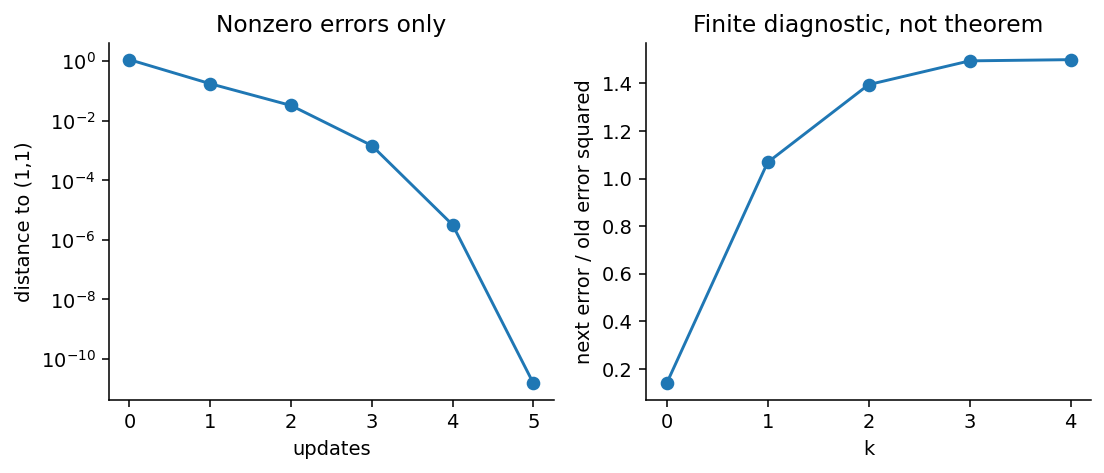

represented zero errors: [6]


In [10]:
arr=np.array([s['theta']for s in paths['square_newton']['states']]);err=np.linalg.norm(arr-[1,1],axis=1);idx=np.arange(len(err));valid=err>0
fig,axes=plt.subplots(1,2,figsize=(8,3.5));axes[0].semilogy(idx[valid],err[valid],'o-');axes[0].set(xlabel='updates',ylabel='distance to (1,1)',title='Nonzero errors only')
ratio=[err[k+1]/err[k]**2 if err[k]>0 and err[k+1]>0 else np.nan for k in range(len(err)-1)];axes[1].plot(range(len(ratio)),ratio,'o-');axes[1].set(xlabel='k',ylabel='next error / old error squared',title='Finite diagnostic, not theorem');show(fig)
print('represented zero errors:',np.flatnonzero(err==0).tolist())

## 10 已记录的真实计时
本格读取作者运行benchmark.py的实际结果，明确不在Notebook中重新计时。图重新从全部原始时间绘制。要测你的机器，另外运行该脚本；不要要求时间文件逐字节一致。

measurement contract ['input generation and one warmup per method excluded from timed intervals', 'entire optimize call included: validation, method setup, every requested row f/g/H computation, factorization, line search and final curvature diagnostic', 'no precomputed Hessian or factorization cache offered to any method', 'pedagogical BFGS literally forms V C V.T and checks Cholesky every accepted update; these O(d^3) operations are timed, unlike an optimized O(d^2) rank-two implementation', 'all timed runs trace=False; scalar stopping state and operation counters remain enabled', 'five default raw repetitions with rotating orders; median/range describe only this run', 'tracemalloc run is separate from timing; Python-traced allocations are not complete native RSS or BLAS workspace', 'resident array bytes count parameter, gradient and H/C/history state; exclude data, model, trace, temporaries and native workspace', 'temporary scale is one representative array size, not a measured peak

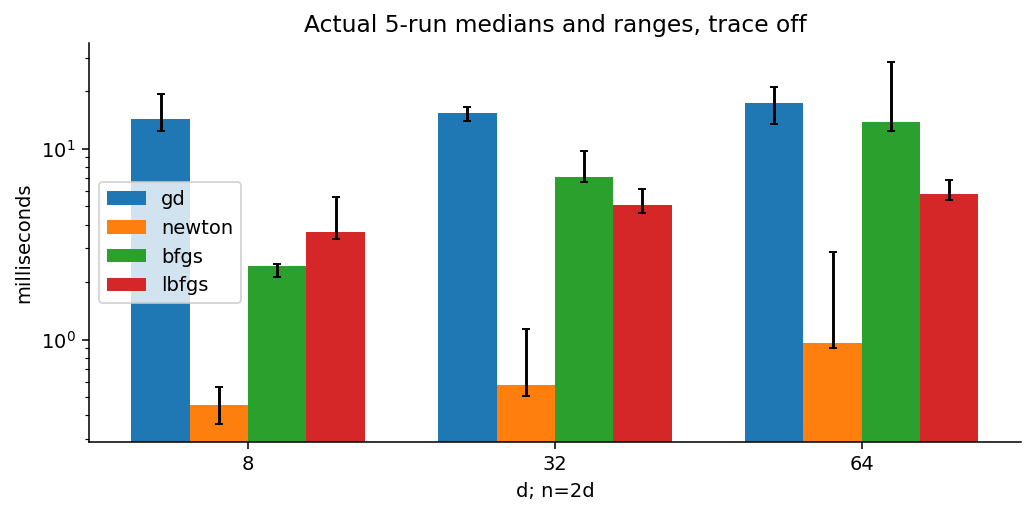

In [11]:
bench=json.loads((ROOT/'benchmark-result.json').read_text());print('measurement contract',bench['measurement_contract'])
fig,ax=plt.subplots(figsize=(7.5,3.8));xx=np.arange(len(bench['designs']));w=.19
for i,m in enumerate(ex.METHODS):
    times=[np.array([r['elapsed_ns']for r in d['methods'][m]['raw_runs']])/1e6 for d in bench['designs']];med=np.array([np.median(v)for v in times]);lo=np.array([v.min()for v in times]);hi=np.array([v.max()for v in times]);ax.bar(xx+(i-1.5)*w,med,w,label=m,yerr=[med-lo,hi-med],capsize=2)
    print(m,'all target flags',[[r['target_met']for r in d['methods'][m]['raw_runs']]for d in bench['designs']])
ax.set(xticks=xx,xticklabels=[d['d']for d in bench['designs']],xlabel='d; n=2d',ylabel='milliseconds',yscale='log',title='Actual 5-run medians and ranges, trace off');ax.legend();show(fig)

## 11 内存读数也必须注明遗漏
左为算法保留数组，右为单独运行的Python跟踪峰值。后者不是全进程RSS，不能拿两个读数相减解释所有原生分配。

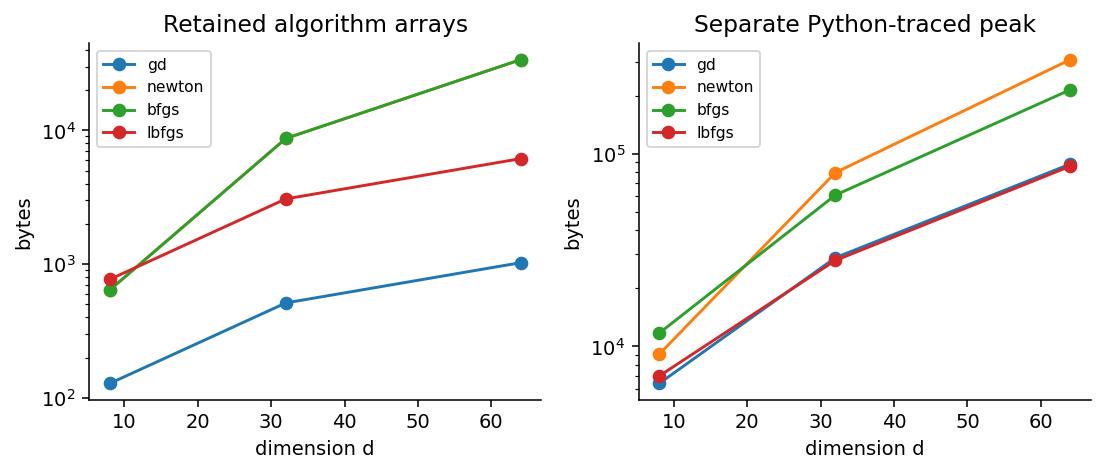

In [12]:
fig,axes=plt.subplots(1,2,figsize=(8,3.5));dims=[d['d']for d in bench['designs']]
for m in ex.METHODS:
    axes[0].plot(dims,[d['methods'][m]['algorithm_state_nbytes']for d in bench['designs']],'o-',label=m);axes[1].plot(dims,[d['methods'][m]['python_traced_peak_increment_bytes']for d in bench['designs']],'o-',label=m)
for ax,title in zip(axes,['Retained algorithm arrays','Separate Python-traced peak']):ax.set(xlabel='dimension d',ylabel='bytes',yscale='log',title=title);ax.legend(fontsize=8)
show(fig)

## 12 实际SciPy API对照
本格真实调用库。BFGS求解器、策略类与L-BFGS-B并非同一算法接口，不断言未对齐线搜索的轨迹相等。

In [13]:
import library_check
library=library_check.run_library()
print('actual versions',library['numpy'],library['scipy'])
for r in library['optimizer_results']:print(r)
print('BFGS strategy',library['strategy']);print('Wolfe line search',library['actual_line_search'])

actual versions 2.3.5 1.17.0
{'model': 'linear', 'method': 'BFGS', 'success': True, 'status': 0, 'message': 'Optimization terminated successfully.', 'iterations': 5, 'nfev': 6, 'njev': 6, 'theta': [1.0000000000000604, 1.0000000000000013], 'f': 0.125, 'gradient': [6.039613253960852e-14, 5.329070518200751e-15], 'gradient_norm_2': 6.063078276197591e-14, 'gradient_target_2_met': True, 'hessian_eigenvalues': [1.0, 4.0], 'custom_status': 'gradient_stationary', 'custom_f': 0.125, 'custom_gradient_norm': 2.228664865928395e-12, 'comparison_note': 'different line searches/stopping norms: no iterate equality assertion'}
{'model': 'linear', 'method': 'L-BFGS-B', 'success': True, 'status': 0, 'message': 'CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL', 'iterations': 9, 'nfev': 10, 'njev': 10, 'theta': [1.0000000000073208, 1.0000000000019826], 'f': 0.125, 'gradient': [7.320810624378282e-12, 7.930545109502418e-12], 'gradient_norm_2': 1.0792952048993021e-11, 'gradient_target_2_met': True, 'hessian_e

## 13 坏末字段与故障状态
哨兵确认非法状态不会进入回调；失败回溯必须保持旧参数。

In [14]:
class Sentinel:
    d=2;counts={'f':0,'g':0,'H':0}
    def evaluate(self,*args):raise RuntimeError('非法输入仍进入回调')
for kwargs in [{'C0':[[1,0],[0,False]]},{'history':[([1,0],[1,0]),([1,0],[1,False])]}]:
    try:ex.optimize(Sentinel(),[0,1],spec,'lbfgs',**kwargs)
    except ValueError as err:print('before callback:',err)
    else:raise RuntimeError('守卫失效')
limited=dict(spec,max_line_trials=1);failure=ex.optimize(ex.RowObjective(x,y,'linear'),[0,0],limited,'bfgs')
print(failure['status'],failure['theta']);print('stationary result',paths['stationary_newton']['status'])
if failure['theta']!=[0.,0.]:raise RuntimeError('失败试点被提交')

before callback: initial inverse approximation must be a real native scalar
before callback: history y must be a real native scalar
line_search_exhausted [0.0, 0.0]
stationary result stationary_indefinite


## 14 独立代数审计与完整JSON
本格运行独立Fraction/Decimal/双循环核验，保存当前核心报告。命令行audit.py另执行完整文件保护子进程测试。

In [15]:
from audit import run_audit
audit=run_audit(cli=False);print('independent checks',audit['groups'])
body=ex.serialized(report);digest=hashlib.sha256(body).hexdigest()
if digest!=audit['report_sha256']:raise RuntimeError('whole report mismatch')
ex.safe_write(ROOT/'notebook_results','report.json',body)
print('full deterministic report SHA256',digest,'bytes',len(body))
print('Recorded times vary on rerun; only deterministic core equality is asserted.')

independent checks {'fraction_checks': 806, 'decimal_difference_checks': 352, 'bfgs_lbfgs_checks': 2401, 'trace_and_failure_checks': 978, 'precallback_guards': 26, 'file_guards': 0}


full deterministic report SHA256 62d232cb551f1967f5f938f5fc92349b45fa87b99a0678b7b24645ba5d8b4be2 bytes 6772586
Recorded times vary on rerun; only deterministic core equality is asserted.
